<a href="https://colab.research.google.com/github/roshelinanusiya/INTERNSHIP/blob/main/preprocess_visual_and_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

Load Dataset

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


Dataset Information

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


Check Null Values

In [4]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


Remove Duplicates

In [5]:
df = df.drop_duplicates()
print("Duplicates Removed")

Duplicates Removed


Label Encoding

In [6]:
le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])
print(df.head())

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  
0                        1          72             72             74  
1                        0          69             90             88  
2                        1          90             95             93  
3                        1          47             57             44  
4                        1          76             78             75  


DATA VISUALIZATION & ANALYSIS

Gender Count Plot

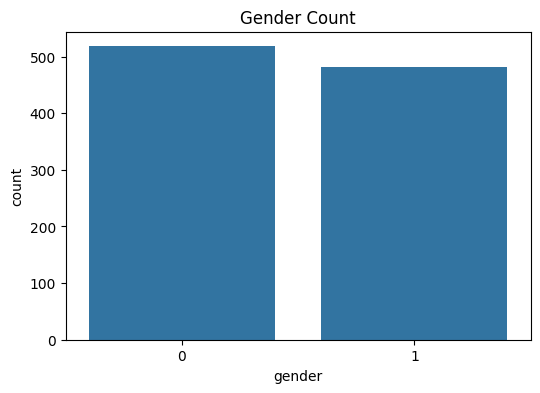

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Count")
plt.show()

Math Score Histogram

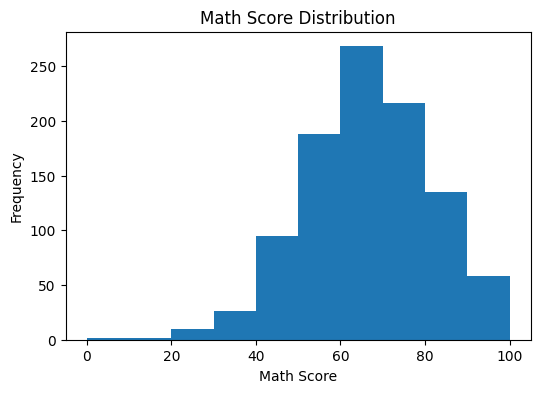

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df['math score'], bins=10)
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()

Scatter Plot

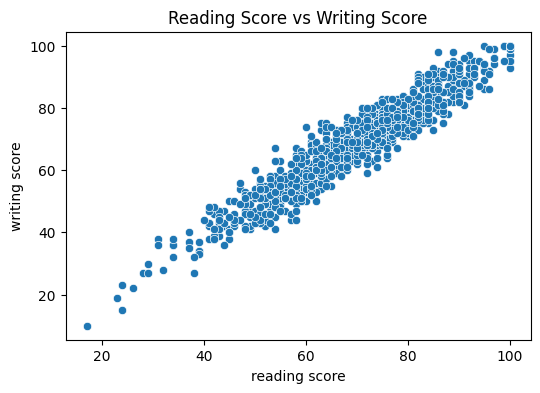

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title("Reading Score vs Writing Score")
plt.show()

Heatmap

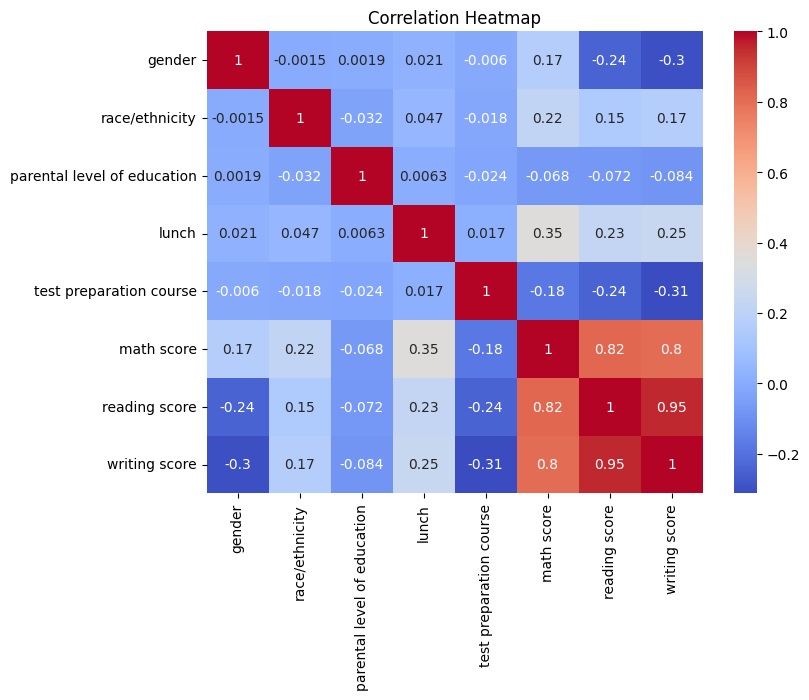

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

MACHINE LEARNING ANALYSIS

Import ML Libraries

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Features and Target

In [12]:
X = df.drop("math score", axis=1)
y = df["math score"]
y = y.apply(lambda x: 1 if x >= 40 else 0)

Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [14]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


Prediction & Accuracy

In [15]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("MODEL ACCURACY")
print(accuracy)

MODEL ACCURACY
0.98



Confusion Matrix


In [16]:
print(confusion_matrix(y_test, y_pred))

[[  7   4]
 [  0 189]]


Classification Report



In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.64      0.78        11
           1       0.98      1.00      0.99       189

    accuracy                           0.98       200
   macro avg       0.99      0.82      0.88       200
weighted avg       0.98      0.98      0.98       200

